# Hafta 4 — Katı Sistemler ve Sınır Değer Problemleri

> **Bilim İnsanları ve Mühendisler için Diferansiyel Denklemler**  
> *Açık yöntemler başarısız olduğunda: katılık, BDF şemaları, atış ve sonlu farklar.*

---

## Öğrenme Hedefleri

1. **Katılığı (stiffness)** katılık oranı ve kararlılık bölgesi analizi yoluyla biçimsel tanımlamak
2. Kapalı Taylor serisinden **Geri Euler** ve **BDF-2**'yi türetmek
3. Katı sistemleri sıfırdan **kapalı Euler** ile çözmek (doğrusal olmayan problemler için Newton iterasyonu)
4. **Sınır Değer Problemlerini** **atış yöntemiyle** formüle etmek ve çözmek
5. SDP'lerin **sonlu fark ayrıklaştırmasını** ve **Thomas algoritmasını** uygulamak


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import brentq

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
})

---

## 1. Katılık — Tanım ve Patoloji

Bir sistem $\mathbf{y}' = \mathbf{f}(t, \mathbf{y})$, Jacobian'ı $J = \partial \mathbf{f}/\partial \mathbf{y}$'nin özdeğerleri $\lambda_i$ şunu sağlıyorsa **katı**dır:

$$\text{Katılık oranı} = \frac{\max_i |\text{Re}(\lambda_i)|}{\min_i |\text{Re}(\lambda_i)|} \gg 1$$

Açık yöntemler, $h|\lambda|$'nin **kararlılık bölgesi** içinde olmasını gerektirir. RK4 için, negatif reel eksen boyunca kararlılık bölgesi yalnızca $|h\lambda| \leq 2.79$'a kadar uzanır; bu da çözüm pürüzsüz olsa bile çok küçük adım boyutlarını zorlar.

### Robertson Kimyasal Kinetik Problemi

$$\dot{y}_1 = -0.04\,y_1 + 10^4\,y_2 y_3$$
$$\dot{y}_2 = 0.04\,y_1 - 10^4\,y_2 y_3 - 3\times10^7\,y_2^2$$
$$\dot{y}_3 = 3\times10^7\,y_2^2$$

Özdeğerler $O(10^{-4})$'ten $O(10^{11})$'e uzanır — katılık oranı $\sim 10^{15}$.

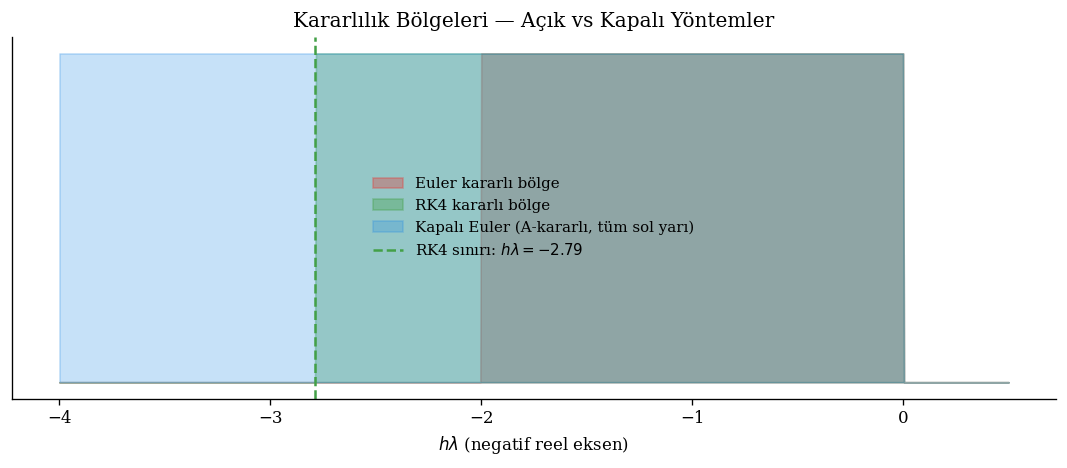

In [2]:
# --- Kararlılık bölgesi karşılaştırması: negatif reel eksen boyunca Euler vs RK4 ---
h_lambda = np.linspace(-4, 0.5, 1000)  # h*lambda değerleri

# Euler kararlılığı: |1 + h*lambda| <= 1  => bölge -1 merkezli yarıçap 1 diski
euler_kararli = np.abs(1 + h_lambda) <= 1.0

# RK4 kararlılık fonksiyonu: R(z) = 1 + z + z^2/2 + z^3/6 + z^4/24
z = h_lambda
R_rk4 = 1 + z + z**2/2 + z**3/6 + z**4/24
rk4_kararli = np.abs(R_rk4) <= 1.0

# Kapalı Euler: R(z) = 1/(1-z)  -> Re(z) < 0 için her zaman kararlı
kapali_euler_kararli = np.abs(1.0 / (1 - h_lambda)) <= 1.0

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(h_lambda, 0, euler_kararli.astype(float),
                alpha=0.35, color='#E53935', label='Euler kararlı bölge')
ax.fill_between(h_lambda, 0, rk4_kararli.astype(float),
                alpha=0.35, color='#43A047', label='RK4 kararlı bölge')
ax.fill_between(h_lambda, 0, kapali_euler_kararli.astype(float),
                alpha=0.25, color='#1E88E5', label='Kapalı Euler (A-kararlı, tüm sol yarı)')

ax.axvline(-2.79, color='#43A047', ls='--', lw=1.5, label='RK4 sınırı: $h\\lambda=-2.79$')
ax.set_xlabel('$h\\lambda$ (negatif reel eksen)')
ax.set_title('Kararlılık Bölgeleri — Açık vs Kapalı Yöntemler')
ax.set_yticks([])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

---

## 2. Geri (Kapalı) Euler

$f(t_n, y_n)$ kullanmak yerine, **gelecekteki** eğimi kullanın:

$$\boxed{y_{n+1} = y_n + h\,f(t_{n+1}, y_{n+1})}$$

Bu **koşulsuz kararlıdır** (A-kararlı). Doğrusal $f = \lambda y$ için:

$$y_{n+1} = \frac{y_n}{1 - h\lambda}$$

Doğrusal olmayan problemler için, her adımda kapalı denklemi **Newton yöntemiyle** çözeriz.

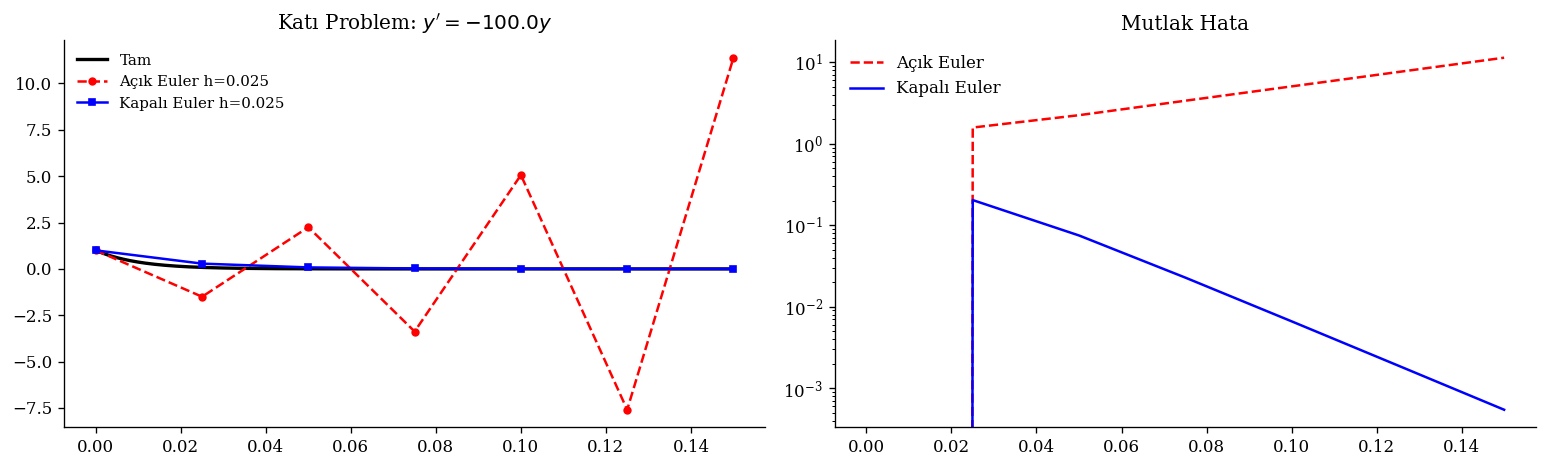

In [3]:
def kapali_euler_dogrusal(lam, t0, y0, T, h):
    """Doğrusal skaler problem y' = lambda*y için kapalı Euler."""
    t_dizi = np.arange(t0, T + h/2, h)
    y_dizi = np.zeros(len(t_dizi))
    y_dizi[0] = y0
    for n in range(len(t_dizi) - 1):
        y_dizi[n+1] = y_dizi[n] / (1 - h * lam)
    return t_dizi, y_dizi


# Gösterim: lambda = -100 ile katı problem
# Tam: y = exp(-100t), T=1 ölçeğinde pürüzsüz ama katı
lam = -100.0
T = 0.15
t_tam = np.linspace(0, T, 500)
y_tam = np.exp(lam * t_tam)

fig, eksenler = plt.subplots(1, 2, figsize=(13, 4))

# Büyük h ile açık Euler
h_acik = 0.025   # > 2/100 = kararlılık sınırı
t_e = np.arange(0, T + h_acik/2, h_acik)
y_e = np.zeros(len(t_e)); y_e[0] = 1.0
for n in range(len(t_e)-1):
    y_e[n+1] = y_e[n] + h_acik * lam * y_e[n]

# Aynı h ile kapalı Euler
t_i, y_i = kapali_euler_dogrusal(lam, 0, 1.0, T, h_acik)

eksenler[0].plot(t_tam, y_tam, 'k-', lw=2, label='Tam')
eksenler[0].plot(t_e, y_e, 'r--o', ms=4, lw=1.5, label=f'Açık Euler h={h_acik}')
eksenler[0].plot(t_i, y_i, 'b-s', ms=4, lw=1.5, label=f'Kapalı Euler h={h_acik}')
eksenler[0].set_title(f'Katı Problem: $y\' = {lam}y$')
eksenler[0].legend(frameon=False, fontsize=9)

eksenler[1].semilogy(t_e, np.abs(y_e - np.exp(lam*t_e)), 'r--', label='Açık Euler')
eksenler[1].semilogy(t_i, np.abs(y_i - np.exp(lam*t_i)), 'b-',  label='Kapalı Euler')
eksenler[1].set_title('Mutlak Hata'); eksenler[1].legend(frameon=False)

plt.tight_layout(); plt.show()

---

## 3. Sınır Değer Problemleri — Atış Yöntemi

Bir **SDP**, iki farklı noktada koşullar belirtir:

$$y'' = f(x, y, y'), \quad y(a) = \alpha, \quad y(b) = \beta$$

**Atış yöntemi** bunu bir BDP'ye dönüştürür: $y'(a) = s$ tahmin et, $b$'ye kadar integralle, sonra $y(b) = \beta$'yı yakalamak için $s$'yi ayarla.

Bu, bir kök bulucuyla sıfıra sürdüğümüz **artık** $r(s) = y(b; s) - \beta$'yı tanımlar.

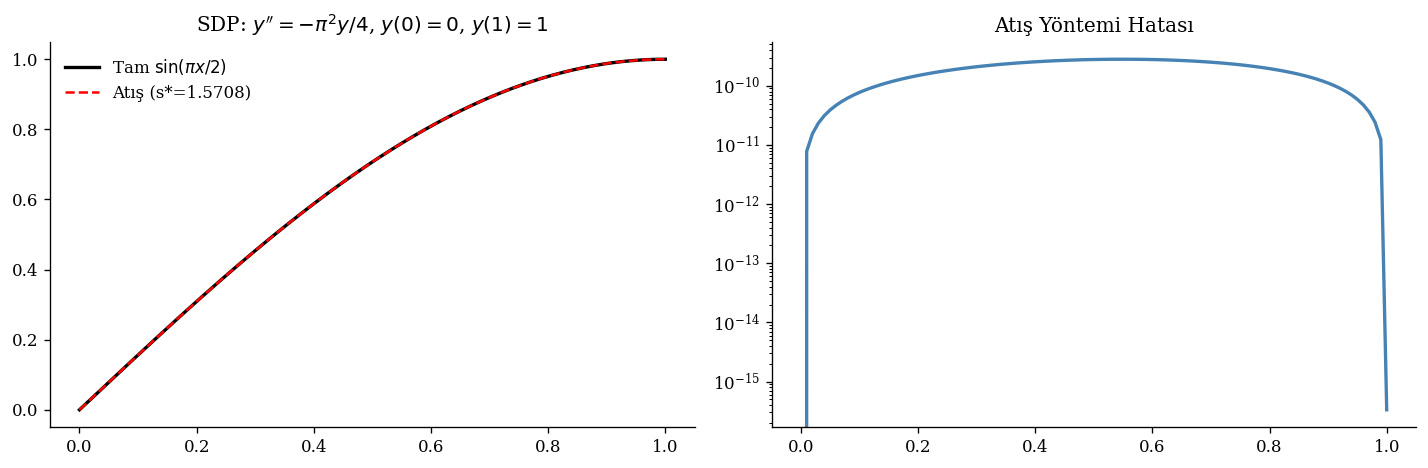

In [4]:
def atis(f_sag, a, alpha, b, beta, s_tahmin, h=0.01):
    """
    SDP y'' = f(x,y,y'), y(a)=alpha, y(b)=beta'yı atış ile çözer.
    f_sag: çağrılabilir(x, y, dy) -> d2y
    Yakınsanmış çözüm için (x_dizi, y_dizi) döndürür.
    """
    def artik(s):
        # BDP integralle: [y, y'], [alpha, s] BK'sı ile a'dan b'ye
        def sis(x, durum):
            y, dy = durum
            return np.array([dy, f_sag(x, y, dy)])

        x_dizi = np.arange(a, b + h/2, h)
        durum = np.array([alpha, s])
        for i in range(len(x_dizi) - 1):
            xi = x_dizi[i]
            k1 = sis(xi,          durum)
            k2 = sis(xi + h/2,    durum + h/2 * k1)
            k3 = sis(xi + h/2,    durum + h/2 * k2)
            k4 = sis(xi + h,      durum + h   * k3)
            durum = durum + h/6 * (k1 + 2*k2 + 2*k3 + k4)
        return durum[0] - beta

    # Kökü parantezle
    s_alt, s_ust = s_tahmin - 5, s_tahmin + 5
    s_yildiz = brentq(artik, s_alt, s_ust, xtol=1e-10)

    # Yakınsanmış eğimle son integrasyon
    def sis(x, durum):
        y, dy = durum
        return np.array([dy, f_sag(x, y, dy)])

    x_dizi = np.arange(a, b + h/2, h)
    durumlar = np.zeros((len(x_dizi), 2))
    durumlar[0] = [alpha, s_yildiz]
    for i in range(len(x_dizi) - 1):
        xi = x_dizi[i]; durum = durumlar[i]
        k1 = sis(xi,        durum)
        k2 = sis(xi + h/2,  durum + h/2*k1)
        k3 = sis(xi + h/2,  durum + h/2*k2)
        k4 = sis(xi + h,    durum + h  *k3)
        durumlar[i+1] = durum + h/6*(k1 + 2*k2 + 2*k3 + k4)

    return x_dizi, durumlar[:, 0], s_yildiz


# --- Örnek: y'' = -pi^2 * y / 4,  y(0)=0, y(1)=1 ---
# Tam: y(x) = sin(pi*x/2) / sin(pi/2) = sin(pi*x/2)
f_sdp = lambda x, y, dy: -np.pi**2 * y / 4.0
x_at, y_at, s_yildiz = atis(f_sdp, a=0, alpha=0, b=1, beta=1, s_tahmin=1.5)
x_tam = np.linspace(0, 1, 400)
y_tam = np.sin(np.pi * x_tam / 2)

fig, eksenler = plt.subplots(1, 2, figsize=(12, 4))
eksenler[0].plot(x_tam, y_tam, 'k-', lw=2, label='Tam $\\sin(\\pi x/2)$')
eksenler[0].plot(x_at, y_at, 'r--', lw=1.5, label=f'Atış (s*={s_yildiz:.4f})')
eksenler[0].set_title("SDP: $y'' = -\\pi^2 y/4$, $y(0)=0$, $y(1)=1$")
eksenler[0].legend(frameon=False)

eksenler[1].semilogy(x_at, np.abs(y_at - np.sin(np.pi*x_at/2)), color='steelblue', lw=2)
eksenler[1].set_title('Atış Yöntemi Hatası')
plt.tight_layout(); plt.show()

---

## 4. SDP'ler için Sonlu Fark Yöntemi

$[a,b]$'yi $h = (b-a)/N$ aralığıyla $N+1$ noktaya ayrıklaştırın.  
İkinci türev **merkezi farkla** yaklaşık hesaplanır:

$$y''_i \approx \frac{y_{i-1} - 2y_i + y_{i+1}}{h^2}$$

Doğrusal bir SDP $y'' + p(x)y' + q(x)y = r(x)$ için bu, **Thomas algoritmasıyla** $O(N)$'de çözülebilen bir **üç köşegenli doğrusal sistem** $A\mathbf{y} = \mathbf{b}$ üretir.

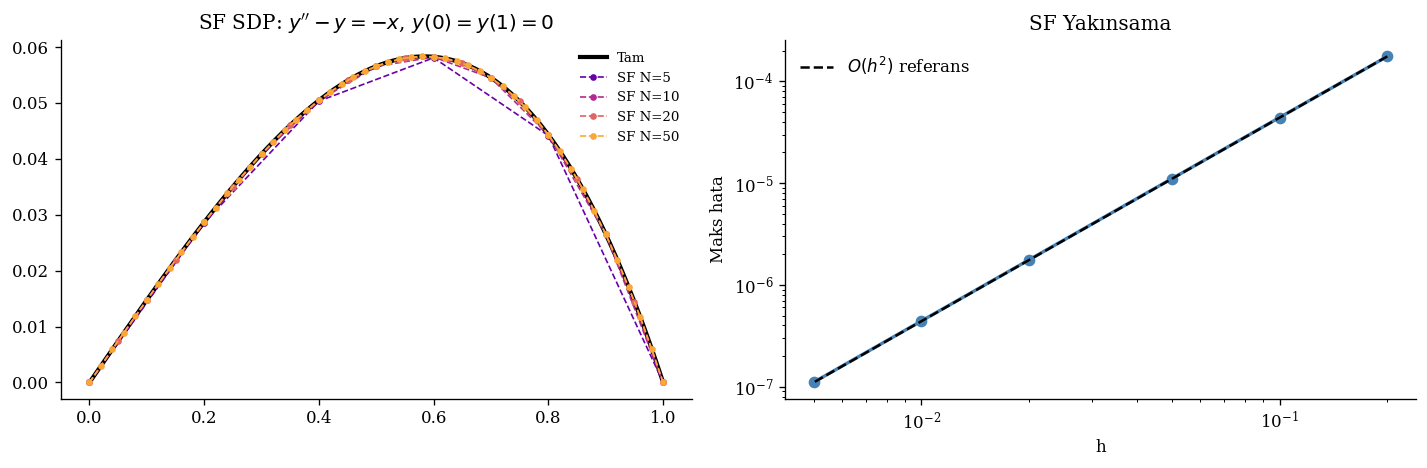

In [5]:
def thomas_algoritmasi(a_alt, b_kosegen, c_ust, d_sag):
    """
    Üç köşegenli sistem Ax=d'yi Thomas algoritması ile O(N)'de çözer.
    a: alt köşegen (uzunluk N-1), b: köşegen (uzunluk N), c: üst köşegen (uzunluk N-1)
    """
    n = len(b_kosegen)
    c_ = np.zeros(n); d_ = np.zeros(n); x = np.zeros(n)

    # İleri tarama
    c_[0] = c_ust[0] / b_kosegen[0]
    d_[0] = d_sag[0] / b_kosegen[0]
    for i in range(1, n):
        payda = b_kosegen[i] - a_alt[i-1] * c_[i-1]
        c_[i] = c_ust[i] / payda if i < n-1 else 0
        d_[i] = (d_sag[i] - a_alt[i-1] * d_[i-1]) / payda

    # Geri yerine koyma
    x[-1] = d_[-1]
    for i in range(n-2, -1, -1):
        x[i] = d_[i] - c_[i] * x[i+1]
    return x


def sf_sdp_dogrusal(p_fonk, q_fonk, r_fonk, a, alpha, b, beta, N):
    """
    y'' + p(x)y' + q(x)y = r(x) için sonlu fark çözücüsü
    Dirichlet SK'ları y(a)=alpha, y(b)=beta ile.
    İç N-1 noktalı ızgarada merkezi farklar O(h^2) kullanır.
    """
    h = (b - a) / N
    x_ic = np.linspace(a, b, N+1)[1:-1]   # N-1 iç nokta
    M = len(x_ic)

    p = np.array([p_fonk(xi) for xi in x_ic])
    q = np.array([q_fonk(xi) for xi in x_ic])
    r = np.array([r_fonk(xi) for xi in x_ic])

    # Köşegen: -2/h^2 + q_i
    b_kosegen = -2.0/h**2 + q
    # Alt köşegen: 1/h^2 - p/(2h)
    a_alt = (1.0/h**2 - p[1:] / (2*h))
    # Üst köşegen: 1/h^2 + p/(2h)
    c_ust = (1.0/h**2 + p[:-1] / (2*h))

    sag = r.copy()
    sag[0]  -= (1.0/h**2 - p[0]/(2*h)) * alpha
    sag[-1] -= (1.0/h**2 + p[-1]/(2*h)) * beta

    y_ic = thomas_algoritmasi(a_alt, b_kosegen, c_ust, sag)
    x_tum = np.concatenate([[a], x_ic, [b]])
    y_tum = np.concatenate([[alpha], y_ic, [beta]])
    return x_tum, y_tum


# --- Örnek: y'' - y = -x, y(0)=0, y(1)=0 ---
# Tam: y = x - sinh(x)/sinh(1)
p_fonk = lambda x: 0.0
q_fonk = lambda x: -1.0
r_fonk = lambda x: -x
y_tam_sdp = lambda x: x - np.sinh(x) / np.sinh(1)

x_tam = np.linspace(0, 1, 400)
fig, eksenler = plt.subplots(1, 2, figsize=(12, 4))
eksenler[0].plot(x_tam, y_tam_sdp(x_tam), 'k-', lw=2.5, label='Tam')

renkler = cm.plasma(np.linspace(0.2, 0.8, 4))
for N, c in zip([5, 10, 20, 50], renkler):
    x_sf, y_sf = sf_sdp_dogrusal(p_fonk, q_fonk, r_fonk, 0, 0, 1, 0, N)
    eksenler[0].plot(x_sf, y_sf, 'o--', color=c, ms=3, lw=1, label=f'SF N={N}')

eksenler[0].set_title("SF SDP: $y'' - y = -x$, $y(0)=y(1)=0$")
eksenler[0].legend(frameon=False, fontsize=8)

N_degerleri = [5, 10, 20, 50, 100, 200]
hatalar = []
for N in N_degerleri:
    x_sf, y_sf = sf_sdp_dogrusal(p_fonk, q_fonk, r_fonk, 0, 0, 1, 0, N)
    hatalar.append(np.max(np.abs(y_sf - y_tam_sdp(x_sf))))

h_degerleri = [1.0/N for N in N_degerleri]
eksenler[1].loglog(h_degerleri, hatalar, 'o-', color='steelblue', lw=2)
eksenler[1].loglog(h_degerleri, np.array(h_degerleri)**2 * hatalar[0]/h_degerleri[0]**2,
               'k--', label='$O(h^2)$ referans')
eksenler[1].set_xlabel('h'); eksenler[1].set_ylabel('Maks hata')
eksenler[1].set_title('SF Yakınsama')
eksenler[1].legend(frameon=False)
plt.tight_layout(); plt.show()

---

## 5. Alıştırmalar

1. **(Katılık)** $y' = -1000(y - \cos t) - \sin t$, $y(0)=0$ için, açık Euler için maksimum kararlı adım boyutu nedir? Euler ile $h = 0.001$, $0.002$, $0.003$'te çözümleri çizin.

2. **(Newton-Kapalı)** Sayısal Jacobian ile Newton yöntemini kullanarak doğrusal olmayan bir kapalı Euler çözücüsü uygulayın. Bunu van der Pol salınıcısına ($\mu=10$) uygulayın.

3. **(BDF-2)** $(t_{n-1},y_{n-1})$, $(t_n,y_n)$, $(t_{n+1},y_{n+1})$'i interpolasyon eden ikinci dereceden polinomdan BDF-2 formülünü türetin. Uygulayın ve mertebe-2 yakınsamasını doğrulayın.

4. **(Atış vs. SF)** $y'' + \pi^2 y = 0$, $y(0)=0$, $y(1)=0$ denklemini çözün (sonsuz çözümü var!). Atış yöntemine ne olur? SF bunu nasıl ele alır?

5. **(Doğrusal olmayan SDP)** Atış yöntemini doğrusal olmayan SDP $y'' = e^y$, $y(0)=y(1)=0$'a (Bratu problemi) uygulayın. Bu parametre değeri için var olan iki çözüm dalını bulun.
